In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

In [9]:
bib = pd.read_csv("SalesD.csv")

In [10]:
bib.head(13)

,Week,Date,Demand
0,1,01/01/2001,98.42
1,2,08/01/2001,122.81
2,3,15/01/2001,100.69
3,4,22/01/2001,100.54
4,5,29/01/2001,114.69
5,6,05/02/2001,105.05
6,7,12/02/2001,102.32
7,8,19/02/2001,118.37
8,9,26/02/2001,112.79
9,10,05/03/2001,115.21


In [11]:
bib.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1331 entries, 0 to 1330
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Week    1331 non-null   int64  
 1   Date    1331 non-null   object 
 2   Demand  1331 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 31.3+ KB


In [12]:
bib.describe()

,Week,Demand
count,1331.000000,1331.000000
mean,666.000000,166.977979
std,384.370915,40.848164
min,1.000000,74.260000
25%,333.500000,133.975000
50%,666.000000,166.640000
75%,998.500000,199.770000
max,1331.000000,256.180000


In [15]:
bib.dtypes

Week        int64
Date       object
Demand    float64
dtype: object

In [16]:
bib.isnull().sum()


Week      0
Date      0
Demand    0
dtype: int64

In [17]:
bib.duplicated().sum()

np.int64(0)

Text(0.5, 1.0, 'HEATMAP FOR ORIGINAL DATASET')

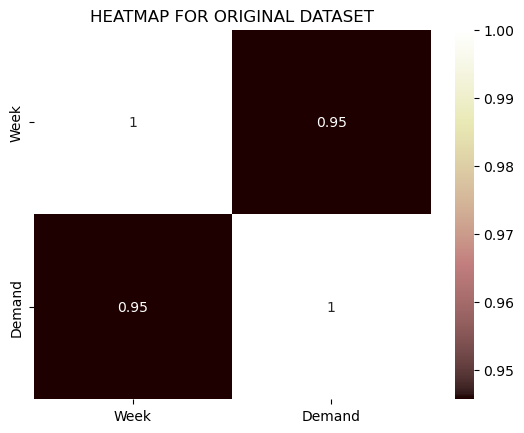

In [19]:
corr= bib.corr(numeric_only=True)
sns.heatmap(corr,
            annot=True,
            cmap= "pink")
plt.title("HEATMAP FOR ORIGINAL DATASET")

In [23]:
bib["Date"]= pd.to_datetime(bib['Date'],dayfirst=True)
bib = bib.sort_values('Date')
bib.set_index('Date', inplace=True)
bib.head()

,Week,Demand
Date,,
2001-01-01,1,98.42
2001-01-08,2,122.81
2001-01-15,3,100.69
2001-01-22,4,100.54
2001-01-29,5,114.69


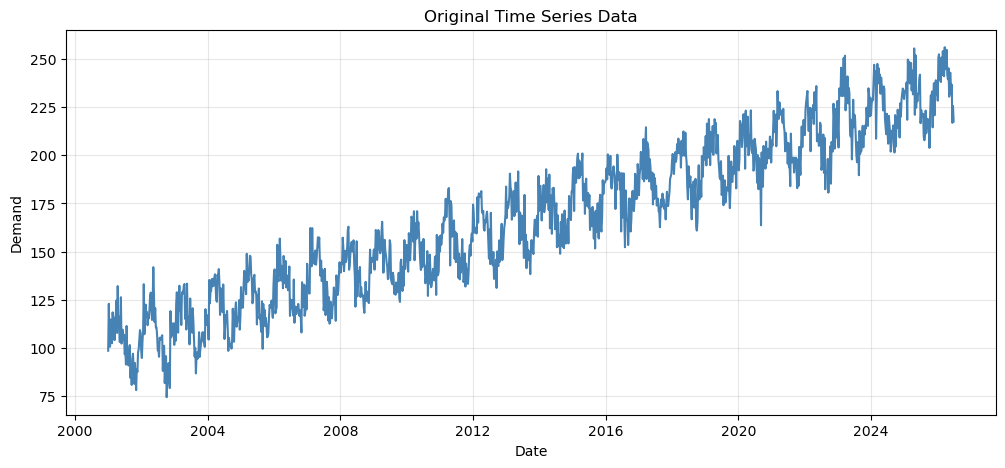

In [26]:
plt.figure(figsize=(12, 5))
plt.plot(bib.index, bib['Demand'], color='steelblue')
plt.title('Original Time Series Data')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.grid(alpha=0.3)
plt.show()

In [30]:
# Augmented Dickey-Fuller test for stationarity
result = adfuller(bib['Demand'])
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")

if result[1] < 0.05:
    print("Data is likely stationary")
else:
    print("Data is likely NOT stationary — differencing may be needed")

ADF Statistic: -1.5589
p-value: 0.5042
Data is likely NOT stationary — differencing may be needed


In [31]:
# Apply first-order differencing
bib['Demand_diff'] = bib['Demand'].diff()

# The first row will be NaN (nothing to subtract from), so drop it
bib_diff = bib['Demand_diff'].dropna()

bib_diff.head()

Date
2001-01-08    24.39
2001-01-15   -22.12
2001-01-22    -0.15
2001-01-29    14.15
2001-02-05    -9.64
Name: Demand_diff, dtype: float64

In [32]:
result_diff = adfuller(bib_diff)
print(f"ADF Statistic: {result_diff[0]:.4f}")
print(f"p-value: {result_diff[1]:.4f}")

if result_diff[1] < 0.05:
    print("Data is now stationary after 1 differencing (d=1)")
else:
    print("Still NOT stationary — try differencing again (d=2)")

ADF Statistic: -11.9116
p-value: 0.0000
Data is now stationary after 1 differencing (d=1)


What the ADF test actually does:
It's a statistical test that checks: "Does this data have a trend, or is it just wobbling around a fixed average?"
How to read the result:

p-value < 0.05 - data is stationary (no real trend, good to go)
p-value ≥ 0.05 - data is NOT stationary (has a trend, needs fixing before ARIMA works properly)

Think of the ADF test as a health check you run before building the model. it tells you whether your data needs "differencing" (explained below) before ARIMA can use it properly.

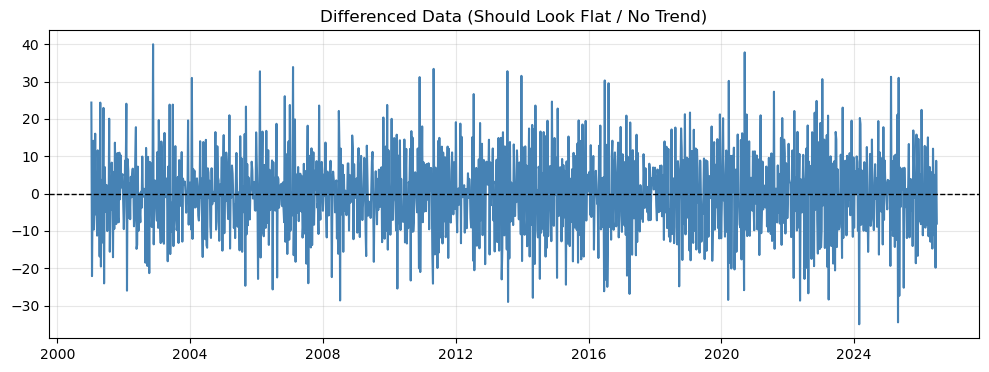

In [34]:
plt.figure(figsize=(12, 4))
plt.plot(bib_diff.index, bib_diff, color='steelblue')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Differenced Data (Should Look Flat / No Trend)')
plt.grid(alpha=0.3)
plt.show()

In [37]:
bib_diff

Date
2001-01-08    24.39
2001-01-15   -22.12
2001-01-22    -0.15
2001-01-29    14.15
2001-02-05    -9.64
              ...  
2026-06-01   -11.17
2026-06-08     5.03
2026-06-15   -19.86
2026-06-22     8.77
2026-06-29    -8.05
Name: Demand_diff, Length: 1330, dtype: float64

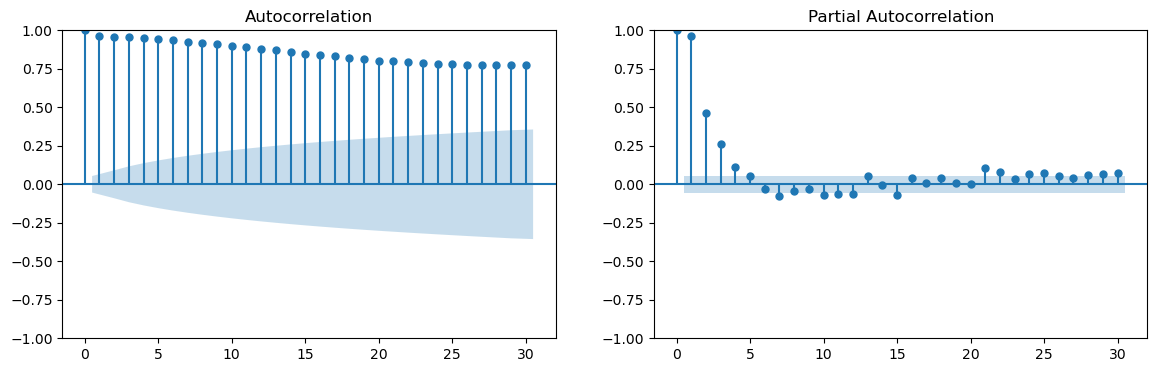

In [38]:
# ACF and PACF plots help identify p and q values for ARIMA
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(bib['Demand'], ax=axes[0], lags=30)
plot_pacf(bib['Demand'], ax=axes[1], lags=30)
plt.show()

ACF (Autocorrelation Function)
Imagine asking: "Is today's value related to yesterday's? What about 2 days ago? 3 days ago?" ACF answers this for every possible gap ("lag") and plots it as bars. A tall bar at lag 3 means "today's value is strongly related to the value from 3 periods ago."


PACF (Partial Autocorrelation Function)
This is a stricter version of the same question. It asks: "Is today's value related to 3 days ago, after already accounting for the relationship with 1 day ago and 2 days ago?" It isolates the direct effect of each lag, removing the indirect "chain reaction" effect.



Analogy: Imagine your mood today might be influenced by yesterday, which was influenced by the day before, which was influenced by the day before that. ACF shows you the whole chain of influence. PACF strips away the middleman effects and shows you only the direct link between today and each specific past day.
You look at where these bars drop off sharply (become insignificant), that drop-off point hints at good values for p and q, explained next.

In [40]:
# Split data: last 20 weeks reserved for testing model accuracy
train = bib['Demand'][:-20]
test = bib['Demand'][-20:]

print("Training size:", len(train))
print("Testing size:", len(test))

Training size: 1311
Testing size: 20


In [41]:
# Fit ARIMA model
# order=(p, d, q) — adjust based on ACF/PACF plots and ADF test result
# Common starting point: (1,1,1) — refine after reviewing diagnostics
model = ARIMA(train, order=(1, 1, 1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                 Demand   No. Observations:                 1311
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -4773.100
Date:                Sun, 12 Jul 2026   AIC                           9552.201
Time:                        16:41:18   BIC                           9567.734
Sample:                    01-01-2001   HQIC                          9558.027
                         - 02-09-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1353      0.044     -3.106      0.002      -0.221      -0.050
ma.L1         -0.5358      0.039    -13.657      0.000      -0.613      -0.459
sigma2        85.5354      3.212     26.631      0.0

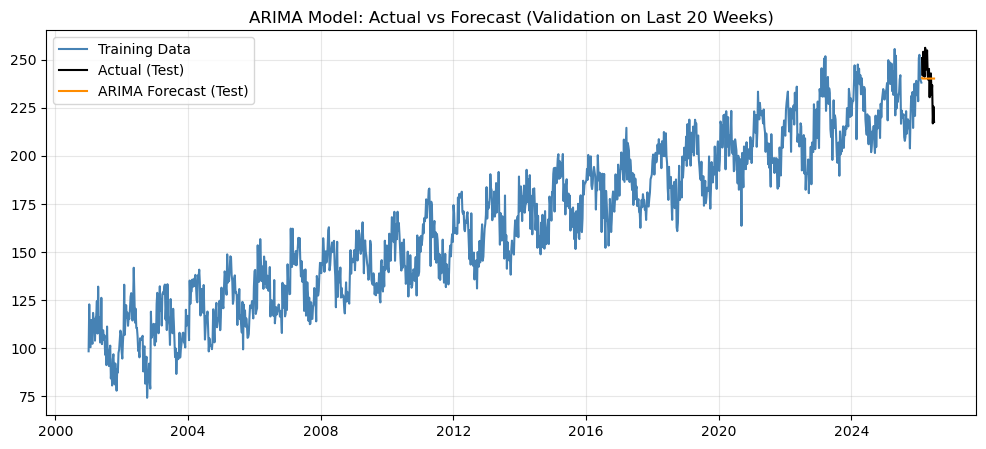

In [42]:
# Forecast the same 20 weeks we held out, to check model accuracy
test_forecast = model_fit.forecast(steps=len(test))
test_forecast.index = test.index

# Compare visually
plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label='Training Data', color='steelblue')
plt.plot(test.index, test, label='Actual (Test)', color='black')
plt.plot(test_forecast.index, test_forecast, label='ARIMA Forecast (Test)', color='darkorange')
plt.title('ARIMA Model: Actual vs Forecast (Validation on Last 20 Weeks)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [46]:
# Refit ARIMA using ALL available data (train + test) for the real future forecast
final_model = ARIMA(bib['Demand'], order=(1, 1, 1))
final_model_fit = final_model.fit()

forecast_horizon = 26  # 6 months ≈ 26 weeks
future_forecast = final_model_fit.forecast(steps=forecast_horizon)

# Build proper future dates
last_date = bib.index[-1]
future_dates = pd.date_range(start=last_date, periods=forecast_horizon + 1, freq='W')[1:]
future_forecast.index = future_dates

future_forecast.head(13)

2026-07-12    223.654913
2026-07-19    222.809010
2026-07-26    222.926992
2026-08-02    222.910537
2026-08-09    222.912832
2026-08-16    222.912512
2026-08-23    222.912556
2026-08-30    222.912550
2026-09-06    222.912551
2026-09-13    222.912551
2026-09-20    222.912551
2026-09-27    222.912551
2026-10-04    222.912551
Freq: W-SUN, Name: predicted_mean, dtype: float64

In [47]:
mae = mean_absolute_error(test, test_forecast)
rmse = np.sqrt(mean_squared_error(test, test_forecast))
mape = np.mean(np.abs((test - test_forecast) / test)) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 8.49
RMSE : 10.89
MAPE : 3.59%


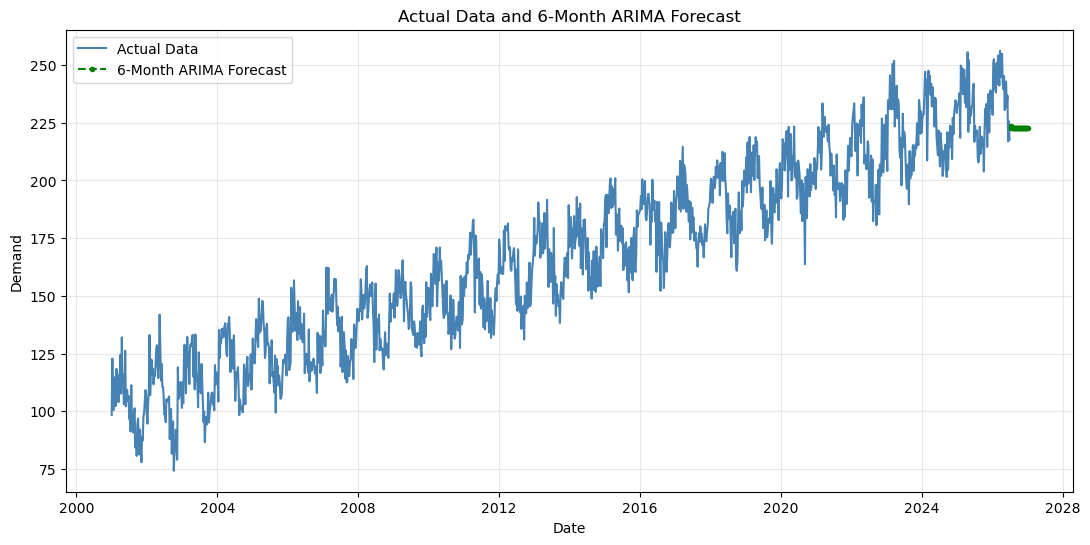

In [51]:
plt.figure(figsize=(13, 6))

plt.plot(bib.index, bib['Demand'], label='Actual Data', color='steelblue')
plt.plot(future_forecast.index, future_forecast, label='6-Month ARIMA Forecast',
         color='green', linestyle='--', marker='o', markersize=3)

plt.title('Actual Data and 6-Month ARIMA Forecast')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
#####Visualize Actual Data + Future Forecast Together